## Goal:

This project is to understand how the student's performance(test score) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch, and Test preparation course.

**1. Data Collection**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

: 

Import the CSV data as pd DataFrame

In [2]:
df = pd.read_csv('StudentsPerformance.csv')

Show the first 5 records

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

**2. Dataset Information**

In [5]:
print("Categories in Gender variable: ", end = " ")
print(df['gender'].unique())

print("Categories in Ethnicity variable: ", end = " ")
print(df['race/ethnicity'].unique())

print("Categories in parental level of education: ", end = " ")
print(df['parental level of education'].unique())

print('Categories in lunch: ', end = " ")
print(df['lunch'].unique())

print('Categories in test preparation course: ', end = ' ')
print(df['test preparation course'].unique())

Categories in Gender variable:  <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in Ethnicity variable:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in parental level of education:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in lunch:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in test preparation course:  <StringArray>
['none', 'completed']
Length: 2, dtype: str


* gender: Male/Female
* race/ethnicity: Group A,B,C,D,E
* parental level of education: bachelor's degree, some college, master's degree, associate's degree, high school, and some high school
* lunch: standard or free/reduced
* test preparation course: None or Completed before test
* math score: score out of 100
* reading score: score out of 100
* writing score: score out of 100
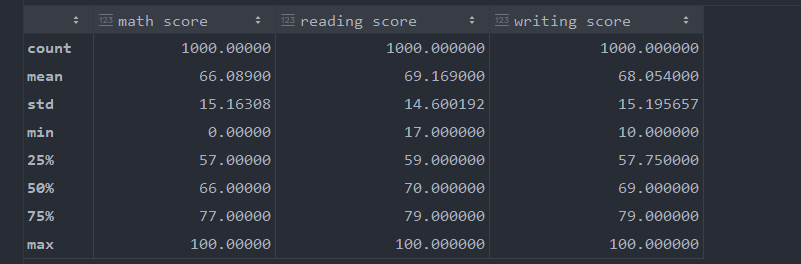

**3. Check Data**

3.1 Check Missing Value

In [6]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

There is no missing value in the dataset

3.2 Check Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

There is no duplicates values in the data set

3.3 Check Data Types

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


3.4 Check the number of unique values of each column

In [9]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

3.5 Check the statistics of data set

In [10]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


* The mean of those three columns are very close with each other - between 66 and 70
* The standard deviation are also close with each other - between 14 and 16
* The min value of math is 0 while the reading_score is 17 and writing_score is 10. (Either that student completely failed the math exam or it is the missing value)

3.7 Exploring the Data

In [11]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


3.8 Adding Total Score and Average column


In [12]:
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total_score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


**4. Visualization**

4.1 Visualizing the average score

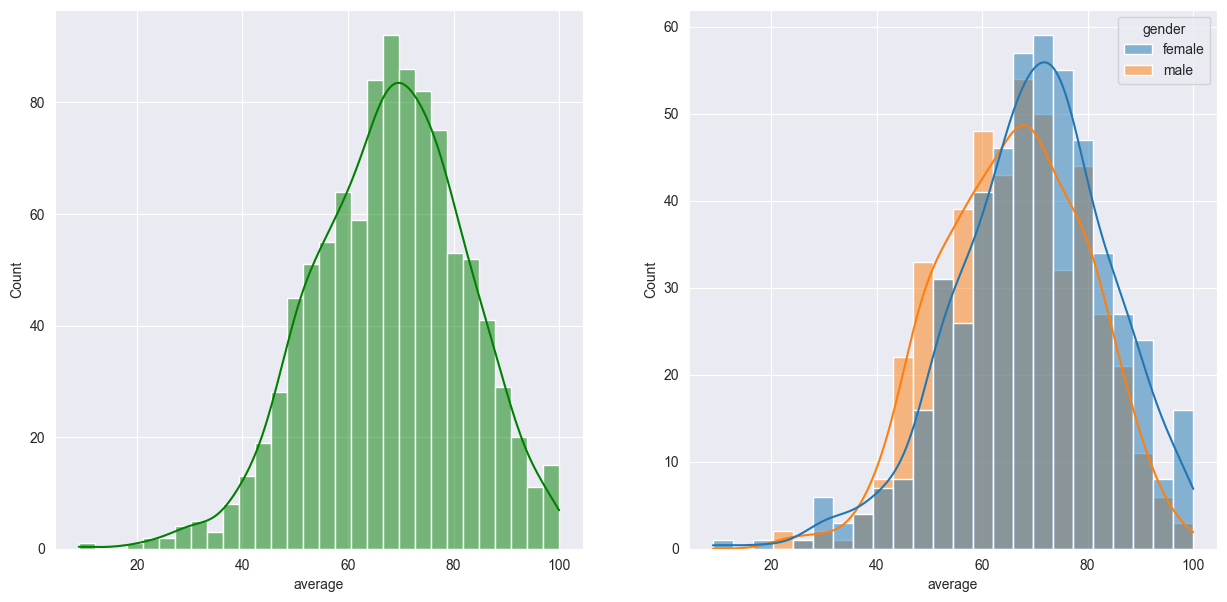

In [14]:
fig, axs = plt.subplots(1, 2, figsize = (15, 7))
plt.subplot(121)
sns.histplot(data = df, x = 'average', bins = 30, kde = True, color = 'green')
plt.subplot(122)
sns.histplot(data = df, x = 'average', kde = True, hue = 'gender')
plt.show()

* The first graph shows that most of the average are between 50-80 and the highest concentration of average is around 70.
* The second graph shows that most of the averages are between 50-90 (female) and 45-80 (male). In addition, the concentration of average is about 75 for female and 65 for male.

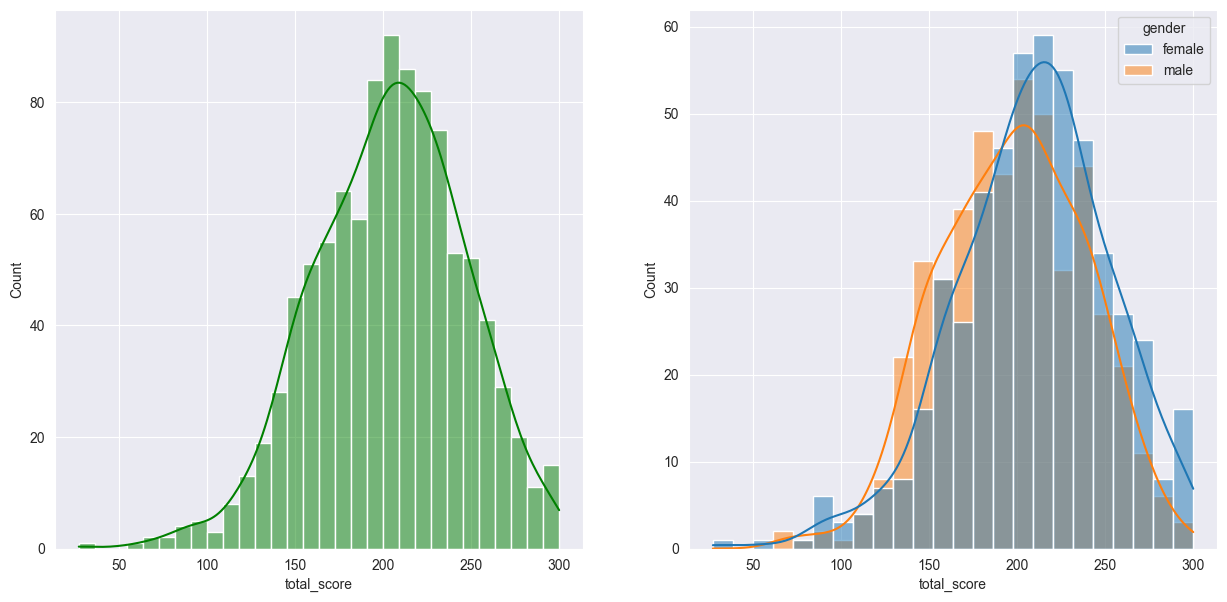

In [15]:
fig, axs = plt.subplots(1,2, figsize = (15,7))
plt.subplot(121)
sns.histplot(data = df, x = 'total_score', bins = 30, kde = True, color  = 'green')
plt.subplot(122)
sns.histplot(data = df, x = 'total_score', kde = True, hue = 'gender')
plt.show()

* The first graph shows that most of the total score are in the range of 150- 250 and the highest concentration of data is at about 230.
* The second graphs shows that most data is in the range of 150-250 for female and 150-200 for male. The highest concentration of data is about 230 for female and 200 for male.

**Insight**: Through the total_score and the average, the female student tends to perform better than male students

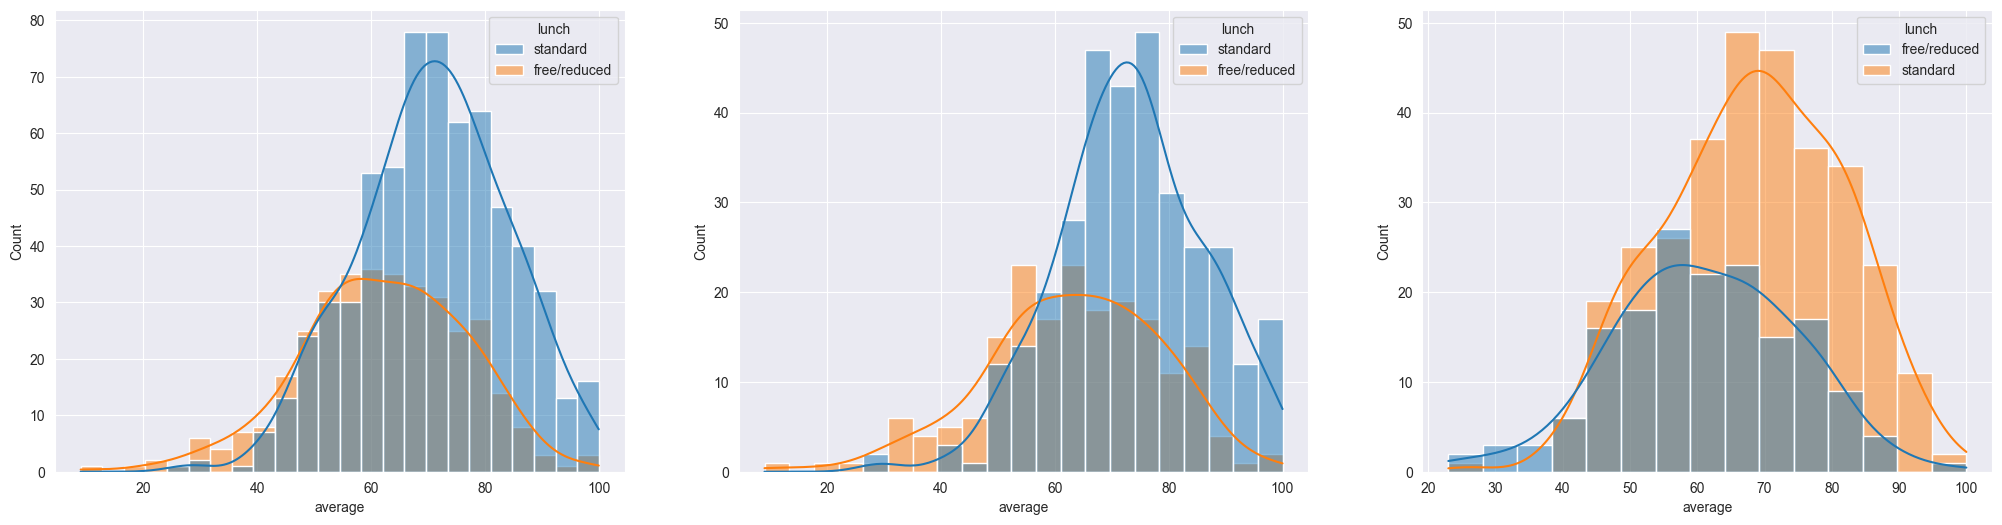

In [16]:
plt.subplots(1, 3, figsize = (25, 6))
plt.subplot(131)
sns.histplot(data = df, x = 'average', kde = True, hue = 'lunch')
plt.subplot(132)
sns.histplot(data = df[df['gender'] == 'female'], x = 'average', kde = True, hue = 'lunch')
plt.subplot(133)
sns.histplot(data = df[df['gender'] == 'male'], x = 'average', kde = True, hue = 'lunch')
plt.show()

* In the first graph, we could see that most average is fall between the range 60-80 for the standard lunch; while the free/reduced lunch is between 45-70. The concentration of average for the standard lunch is at the 75; the concentration of average for the free/reduced lunch is at 60.
* In the second graph, we look at the histogram and the kde of how lunch affect the performance of female student. We could see that most average is fall between 60-80 for the standard lunch and the free/reduced lunch fall between 50-70. In addition, the concentration of average for the standard lunch is about 75 while the free/reduced lunch is about 65.
* In the third graph we look at the histogram and the kde of how lunch affect the performance of male student. We could see that most average is fall between 60-80 for the standard lunch while the free/reduced lunch fall between 45-75. The concentration of average for the standard lunch is about 70 while the free/reduced lunch is about 55

**Insight**: from those three graphs, we could see that the standard lunch helps student perform better in exam whether it is a male or female

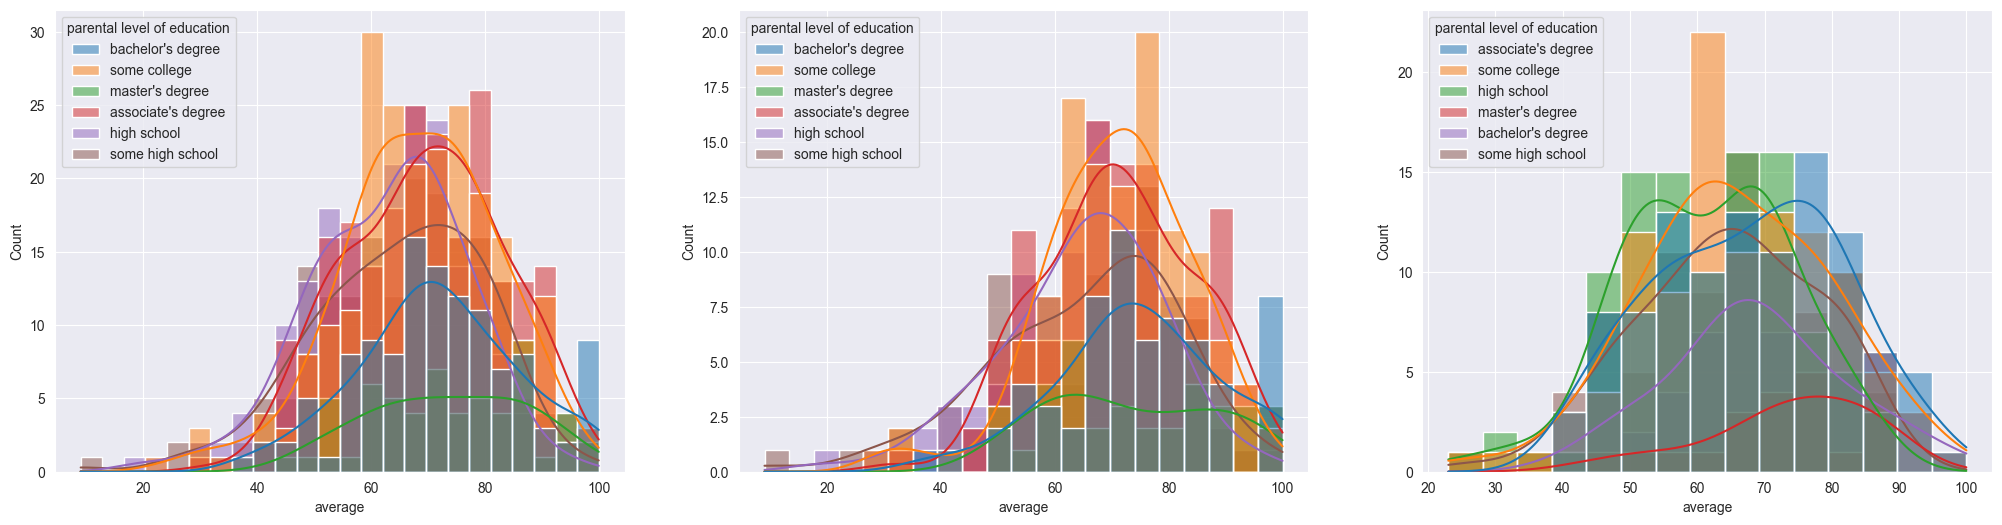

In [17]:
plt.subplots(1, 3, figsize = (25,6))
plt.subplot(131)
ax = sns.histplot(data = df, x = 'average', kde = True, hue = 'parental level of education')
plt.subplot(132)
ax = sns.histplot(data = df[df['gender'] == 'female'], x = 'average', kde = True, hue = 'parental level of education')
plt.subplot(133)
ax = sns.histplot(data = df[df['gender'] == 'male'], x = 'average', kde = True, hue = 'parental level of education')
plt.show()

* In the first graph, student whose parents have higher level of education tend have score distribution shifted toward higher average values. For example, when looking at student who has parent holding a master's degree most commonly score around 60-80 whereas those student whose parents have some high school education have the average is about 50-60. However, there are a substantial overlap among all groups, therefore it shows that while parental education is associated with student performance, it does not a strict determinant.
* In the second graph, female student whose parents have higher level of education is also tend to have score distribution shifted toward higher average values. For example, female student who has parent holding a master's degree are most commonly score about 60-80 score. Comparing with female student whose parents have some high school education have mostly average about 60-70. Despite that there is a substantial overlap between groups, as parental education is associated with female student performance, it does not have big influence on it.
* In the third graph, it is the same for the male student like in the last two graphs. Male student whose parents have higher level of education tend to have the score distribution toward the right. For example, male student whose parent have a master's degree having mostly average score about 70-90. While male student whose parent having some high school education have most commonly average about 60-70. Despite that, when comparing with other groups, there are also have substantial overlap between  groups too, therefore parental education is associated with student performance, yet it is not a strict determinant.

**Insight**: Through three graphs, we could say that parental education is associated with student performance, yet is not a strict determinant in spite of the student gender.

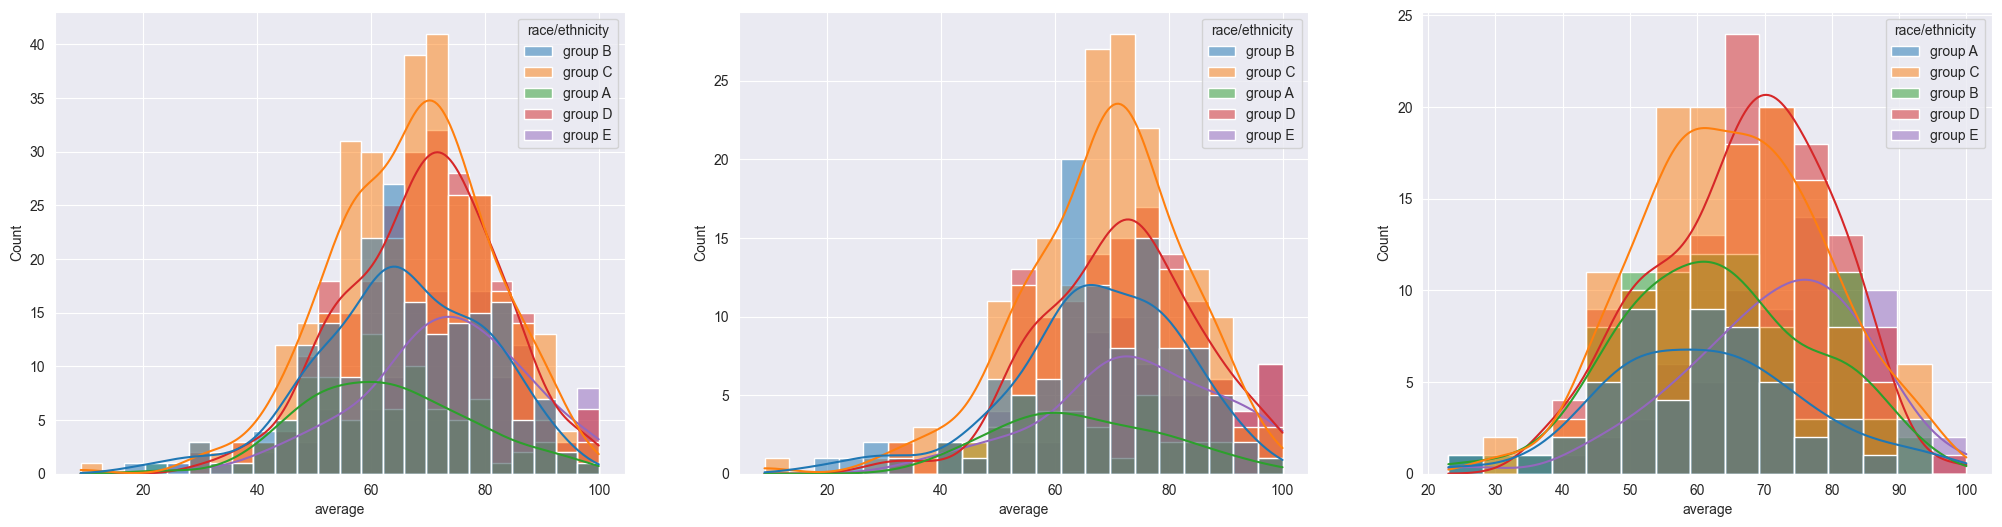

In [18]:
plt.subplots(1,3, figsize = (25, 6))
plt.subplot(131)
ax = sns.histplot(data = df, x = 'average', kde = True, hue = 'race/ethnicity')
plt.subplot(132)
ax = sns.histplot(data = df[df['gender'] == 'female'], x = 'average', kde = True, hue = 'race/ethnicity')
plt.subplot(133)
ax = sns.histplot(data = df[df['gender'] == 'male'], x = 'average', kde = True, hue = 'race/ethnicity')
plt.show()

* In this three graph there is a common things that student with different race tends to influence the average score. For example, student whose in group A have the majority of their average score about 55. While compare with other group of race like group C, they tend to have the majority of average score around 65. This shows that there is an association between the race/ethnicity and the average exam score. However, this is not a strict determinant as there are students in group A still manage to get the high score just like other groups, and vice versa.

4.2: Visualizing the score based on Subjects


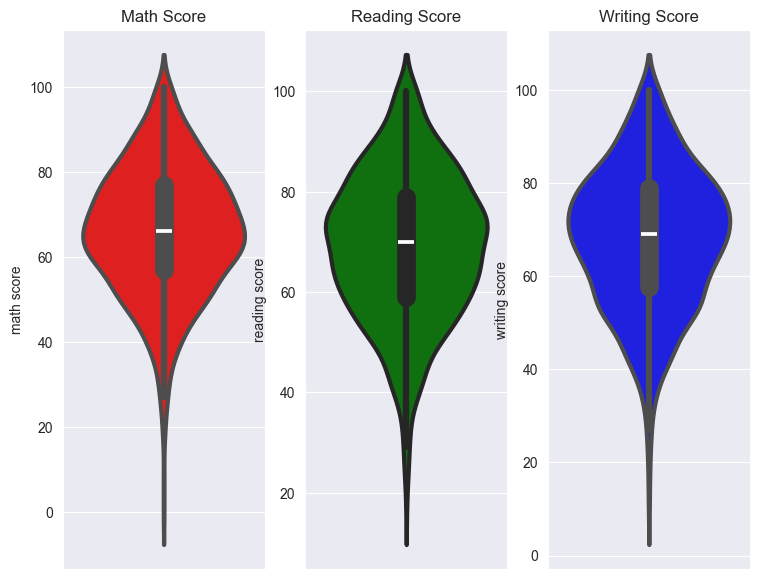

In [19]:
plt.figure(figsize = (12, 7))
plt.subplot(1, 4, 1)
plt.title('Math Score')
sns.violinplot(data = df, y = 'math score', color = 'red', linewidth = 3)
plt.subplot(1, 4, 2)
plt.title('Reading Score')
sns.violinplot(data = df, y = 'reading score', color = 'green', linewidth = 3)
plt.subplot(1, 4, 3)
plt.title('Writing Score')
sns.violinplot(data = df, y = 'writing score', color = 'blue', linewidth = 3)
plt.show()

* From the first violin graph, we could see that the majority of math score is about 65 while the median of it is also 65.
* In the second violin graph, we could see that the majority of the reading score is about 75 while the median is about 70.
* In the third violin graph, we could see that the majority of the writing score is about 70 while the median of the writing score is about 70.

4.3: Multivariate analysis

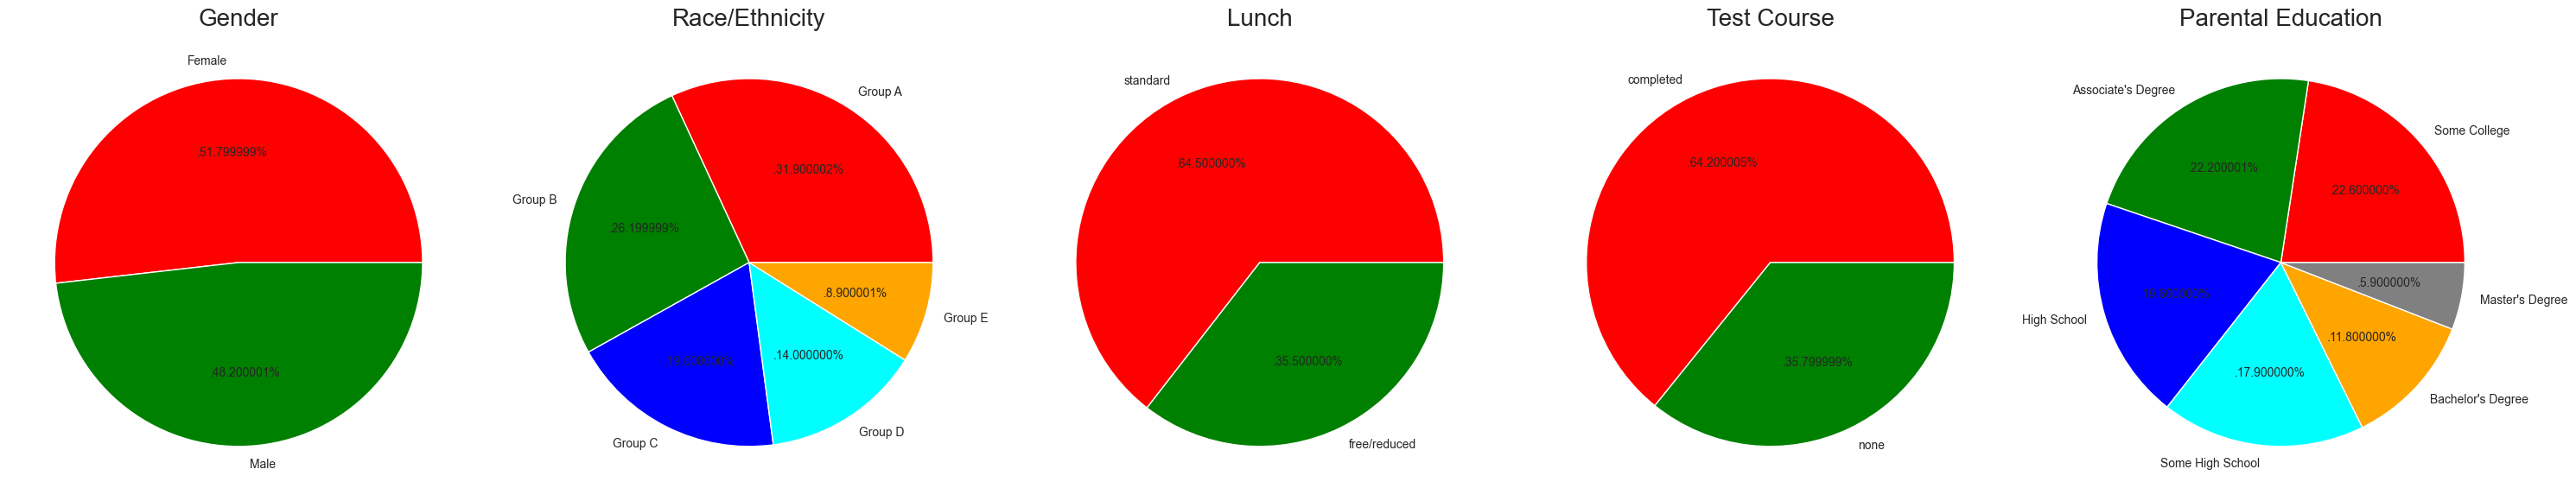

In [23]:
plt.rcParams['figure.figsize'] = (30, 12)
autopct = '.%2f%%'

#Gender pie plot
plt.subplot(1,5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red', 'green']

plt.pie(size, colors = color, labels = labels, autopct = autopct)
plt.title('Gender', fontsize = 20)
plt.axis('off')

#Race/ethnics pie plot
plt.subplot(1,5, 2)
size = df['race/ethnicity'].value_counts()
labels = 'Group A', 'Group B', 'Group C', 'Group D', 'Group E'
color = ['red', 'green', 'blue', 'cyan', 'orange']

plt.pie(size, colors = color, labels = labels, autopct = autopct)
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')

#Lunch pie plot
plt.subplot(1,5,3)
size = df['lunch'].value_counts()
labels = 'standard', 'free/reduced'
color = ['red', 'green']

plt.pie(size, colors = color, labels = labels, autopct = autopct)
plt.title('Lunch', fontsize = 20)
plt.axis('off')

#Test Course
plt.subplot(1,5,4)
size = df['test preparation course'].value_counts()
labels = 'completed', 'none'
color = ['red', 'green']

plt.pie(size, colors = color, labels = labels, autopct = autopct)
plt.title('Test Course', fontsize = 20)
plt.axis('off')

#Parental Education
plt.subplot(1, 5, 5)
size = df['parental level of education'].value_counts()
color = ['red', 'green', 'blue', 'cyan', 'orange']
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = autopct)
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

 **Insight**:
* Number of Male and Female is almost equal
* Number of student are greatest in Group C
* Number of students who have standard lunch are greater
* Number of student who have not enrolled in any test preparation course is greater
* Number of students whose parental education is "Some College" is the greatest and followed closely by "Associate's Degree"